# XGBoost NPL Prediction Model

Trains an XGBoost binary classifier on `IS_NPL` using the pre-split
train/test sets in `EDA/data_spliting/` (80/20), restricted to the same
feature set produced by feature selection (`selected_features_xgboost.csv`).
An internal validation set is carved out of `train` below (test stays an
untouched final holdout) for early stopping, calibration, and threshold
selection.

In [78]:
# ------------------------------------------------------------------
# 1. IMPORTS & CONFIG
# ------------------------------------------------------------------
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
TARGET_COL = 'IS_NPL'

SPLIT_DIR = pathlib.Path(r'C:\Users\koemhort.leng\Desktop\EWS_NPL_V2\EDA\data_spliting')
FEATURE_REF_PATH = pathlib.Path(r'C:\Users\koemhort.leng\Desktop\EWS_NPL_V2\EDA\feature_selection_output\selected_features_xgboost_cleaned.csv')
MODEL_OUT_PATH = pathlib.Path(r'C:\Users\koemhort.leng\Desktop\EWS_NPL_V2\EDA\feature_selection_output\xgb_npl_model.json')


In [79]:
# ------------------------------------------------------------------
# 2. LOAD PRE-SPLIT DATA (train / test only -- internal validation is
#    carved out of train in step 3b below)
# ------------------------------------------------------------------
train_df = pd.read_csv(SPLIT_DIR / 'train.csv')
test_df = pd.read_csv(SPLIT_DIR / 'test.csv')

print('train:', train_df.shape, ' test:', test_df.shape)
for name, d in [('train', train_df), ('test', test_df)]:
    rate = d[TARGET_COL].mean()
    print(f'{name} NPL ratio: {rate:.4%}')


train: (55245, 15)  test: (13812, 15)
train NPL ratio: 15.3896%
test NPL ratio: 15.3852%


In [80]:
# ------------------------------------------------------------------
# 3. RESTRICT TO THE SAME FEATURES CHOSEN DURING FEATURE SELECTION
# ------------------------------------------------------------------
selected_cols = pd.read_csv(FEATURE_REF_PATH, nrows=0).columns.tolist()
feature_cols = [c for c in selected_cols if c != TARGET_COL]

missing_in_train = [c for c in feature_cols + [TARGET_COL] if c not in train_df.columns]
if missing_in_train:
    raise ValueError(f'Columns missing from train split: {missing_in_train}')

train_df = train_df[feature_cols + [TARGET_COL]].copy()
test_df = test_df[feature_cols + [TARGET_COL]].copy()

print(f'Using {len(feature_cols)} features:')
print(feature_cols)


Using 14 features:
['STAFF_OFFICIAL', 'OCCUP_TYPE_DESC', 'OCCUP_DET_DESC', 'PROVINCE', 'DISTRICT', 'COMMUNE', 'VILLAGE', 'AMK_BIRTH_PLACE_DESC', 'PR_REPAY_FREQ', 'PRODUCT_TYPE', 'LOAN_AMOUNT_USD', 'BALANCE_USD', 'CASA_CREDIT_AMOUNT_USD', 'CASA_CREDIT_CNT']


In [81]:
# ------------------------------------------------------------------
# 3b. CARVE AN INTERNAL VALIDATION SET OUT OF TRAIN
# ------------------------------------------------------------------
# test_df stays an untouched final holdout. Early stopping, calibration, and
# threshold selection all need their own held-out data that isn't test --
# carve it from train instead of relying on a separately saved valid.csv.
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df[TARGET_COL], random_state=RANDOM_STATE
)

print(f'Train (fit): {train_df.shape}   Internal valid: {valid_df.shape}   Test: {test_df.shape}')
for name, d in [('train', train_df), ('valid', valid_df), ('test', test_df)]:
    print(f'{name} NPL ratio: {d[TARGET_COL].mean():.4%}')


Train (fit): (44196, 15)   Internal valid: (11049, 15)   Test: (13812, 15)
train NPL ratio: 15.3905%
valid NPL ratio: 15.3860%
test NPL ratio: 15.3852%


In [82]:
# ------------------------------------------------------------------
# 5. DTYPE ALIGNMENT — bools -> int, objects -> category
#    (categories are built from train+valid+test combined so the
#    same codes mean the same thing across all three splits)
# ------------------------------------------------------------------
bool_cols = train_df[feature_cols].select_dtypes(include='bool').columns.tolist()
cat_cols = train_df[feature_cols].select_dtypes(include='object').columns.tolist()

for d in (train_df, valid_df, test_df):
    for col in bool_cols:
        d[col] = d[col].astype('int8')

for col in cat_cols:
    all_categories = pd.concat([train_df[col], valid_df[col], test_df[col]]).astype(str).unique()
    cat_dtype = pd.CategoricalDtype(categories=sorted(all_categories))
    for d in (train_df, valid_df, test_df):
        d[col] = d[col].astype(str).astype(cat_dtype)

print(f'Boolean columns cast to int: {bool_cols}')
print(f'Categorical columns: {cat_cols}')


Boolean columns cast to int: ['STAFF_OFFICIAL']
Categorical columns: ['OCCUP_TYPE_DESC', 'OCCUP_DET_DESC', 'PROVINCE', 'DISTRICT', 'COMMUNE', 'VILLAGE', 'AMK_BIRTH_PLACE_DESC', 'PR_REPAY_FREQ', 'PRODUCT_TYPE']


In [83]:
# ------------------------------------------------------------------
# 6. BUILD X / y FOR EACH SPLIT
# ------------------------------------------------------------------
X_train, y_train = train_df[feature_cols], train_df[TARGET_COL]
X_valid, y_valid = valid_df[feature_cols], valid_df[TARGET_COL]
X_test, y_test = test_df[feature_cols], test_df[TARGET_COL]

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'Train class balance -> neg: {neg}, pos: {pos}, scale_pos_weight: {scale_pos_weight:.3f}')


Train class balance -> neg: 37394, pos: 6802, scale_pos_weight: 5.498


In [84]:
# ------------------------------------------------------------------
# 7. TRAIN XGBOOST CLASSIFIER (native categorical support, early stopping)
# ------------------------------------------------------------------
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='aucpr',
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    early_stopping_rounds=50,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=50,
)

print('Best iteration:', model.best_iteration)


[0]	validation_0-aucpr:0.35436	validation_1-aucpr:0.26916
[50]	validation_0-aucpr:0.47874	validation_1-aucpr:0.33058
[100]	validation_0-aucpr:0.51681	validation_1-aucpr:0.34144
[150]	validation_0-aucpr:0.54572	validation_1-aucpr:0.34478
[200]	validation_0-aucpr:0.57472	validation_1-aucpr:0.34873
[250]	validation_0-aucpr:0.60180	validation_1-aucpr:0.35333
[300]	validation_0-aucpr:0.62510	validation_1-aucpr:0.35728
[350]	validation_0-aucpr:0.64741	validation_1-aucpr:0.36011
[400]	validation_0-aucpr:0.66846	validation_1-aucpr:0.36086
[450]	validation_0-aucpr:0.68686	validation_1-aucpr:0.36028
[460]	validation_0-aucpr:0.69035	validation_1-aucpr:0.36010
Best iteration: 410


--- Validation ---
ROC AUC: 0.7367
PR AUC : 0.363
              precision    recall  f1-score   support

           0     0.9093    0.7710    0.8345      9349
           1     0.3142    0.5771    0.4069      1700

    accuracy                         0.7412     11049
   macro avg     0.6118    0.6740    0.6207     11049
weighted avg     0.8177    0.7412    0.7687     11049



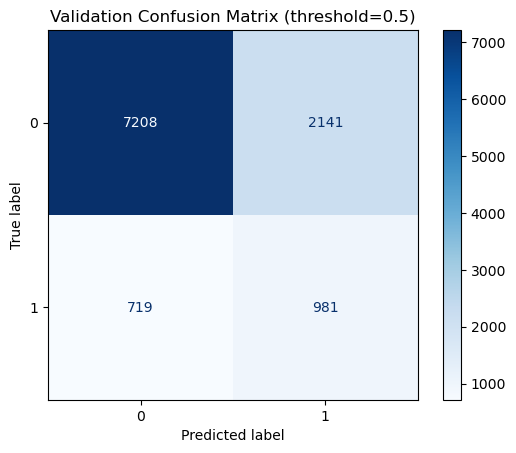

--- Test ---
ROC AUC: 0.7338
PR AUC : 0.3379
              precision    recall  f1-score   support

           0     0.9074    0.7683    0.8321     11687
           1     0.3087    0.5689    0.4002      2125

    accuracy                         0.7376     13812
   macro avg     0.6080    0.6686    0.6161     13812
weighted avg     0.8153    0.7376    0.7656     13812



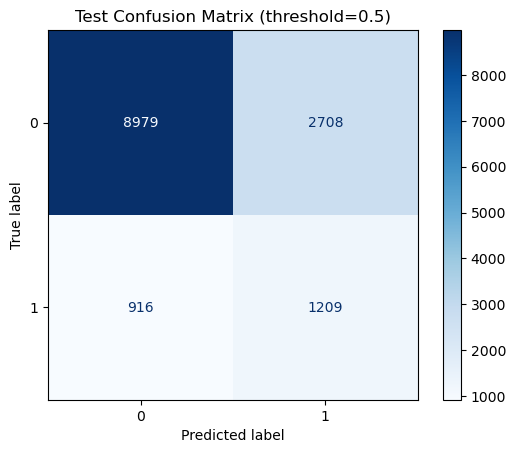

In [85]:
# ------------------------------------------------------------------
# 8. EVALUATE ON VALID & TEST
# ------------------------------------------------------------------
def evaluate(name, X, y, model, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)

    print(f'--- {name} ---')
    print('ROC AUC:', round(roc_auc_score(y, proba), 4))
    print('PR AUC :', round(average_precision_score(y, proba), 4))
    print(classification_report(y, pred, digits=4))

    cm = confusion_matrix(y, pred)
    ConfusionMatrixDisplay(cm).plot(cmap='Blues')
    plt.title(f'{name} Confusion Matrix (threshold={threshold})')
    plt.show()

    return proba, pred

valid_proba, valid_pred = evaluate('Validation', X_valid, y_valid, model)
test_proba, test_pred = evaluate('Test', X_test, y_test, model)


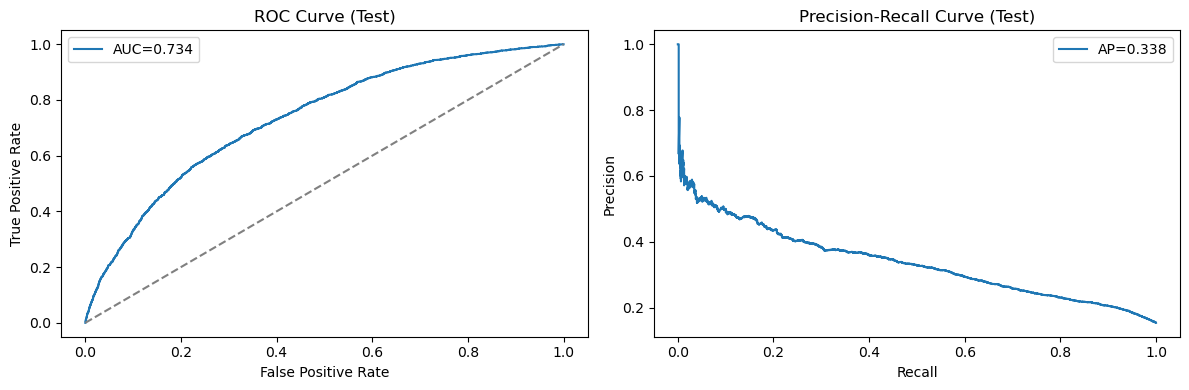

In [86]:
# ------------------------------------------------------------------
# 9. ROC & PRECISION-RECALL CURVES (test set)
# ------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, test_proba)
prec, rec, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, test_proba):.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Test)')
axes[0].legend()

axes[1].plot(rec, prec, label=f'AP={average_precision_score(y_test, test_proba):.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Test)')
axes[1].legend()

plt.tight_layout()
plt.show()


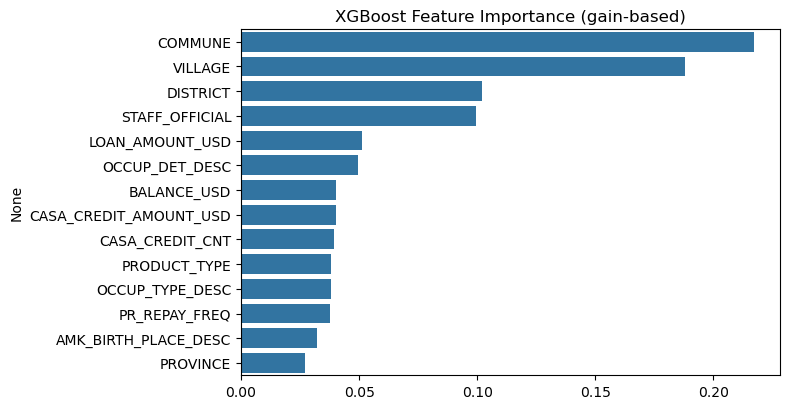

COMMUNE                   0.217320
VILLAGE                   0.187985
DISTRICT                  0.101999
STAFF_OFFICIAL            0.099509
LOAN_AMOUNT_USD           0.051384
OCCUP_DET_DESC            0.049313
BALANCE_USD               0.040171
CASA_CREDIT_AMOUNT_USD    0.040157
CASA_CREDIT_CNT           0.039423
PRODUCT_TYPE              0.037975
OCCUP_TYPE_DESC           0.037946
PR_REPAY_FREQ             0.037553
AMK_BIRTH_PLACE_DESC      0.032023
PROVINCE                  0.027242
dtype: float32

In [87]:
# ------------------------------------------------------------------
# 10. FEATURE IMPORTANCE
# ------------------------------------------------------------------
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, max(4, len(importance) * 0.3)))
sns.barplot(x=importance.values, y=importance.index, orient='h')
plt.title('XGBoost Feature Importance (gain-based)')
plt.tight_layout()
plt.show()

display(importance)


In [88]:
# ------------------------------------------------------------------
# 10b. LEAKAGE CHECK — is any feature basically encoding IS_NPL?
# ------------------------------------------------------------------
# A PR-AUC this close to 1.0 on a ~9% positive target is a red flag for
# target leakage, not a great model. Check which features dominate and
# whether they perfectly (or near-perfectly) separate the classes.

print('Top 10 features by importance:')
display(importance.head(10))

suspect_cols = ['M0_PSC', 'PMS_PASSDUE'] + [c for c in feature_cols if c.startswith('M') and c.endswith('_PSC')]
suspect_cols = [c for c in dict.fromkeys(suspect_cols) if c in train_df.columns]

for col in suspect_cols:
    ct = pd.crosstab(train_df[col], train_df[TARGET_COL], normalize='index')
    print(f'\n{col} vs {TARGET_COL} (row-normalized):')
    display(ct)

# If a column's crosstab shows IS_NPL is ~0 or ~1 for each value of that
# column (near-deterministic), it is leaking the label and should be
# dropped from feature_cols before retraining — especially M0_PSC, which
# is the CURRENT month's status and may be the same signal IS_NPL was
# derived from. M1_PSC..M12_PSC (trailing/historical months) are more
# defensible to keep since they reflect past behavior, not the current
# outcome — but verify with your NPL definition/business rules.


Top 10 features by importance:


COMMUNE                   0.217320
VILLAGE                   0.187985
DISTRICT                  0.101999
STAFF_OFFICIAL            0.099509
LOAN_AMOUNT_USD           0.051384
OCCUP_DET_DESC            0.049313
BALANCE_USD               0.040171
CASA_CREDIT_AMOUNT_USD    0.040157
CASA_CREDIT_CNT           0.039423
PRODUCT_TYPE              0.037975
dtype: float32

In [89]:
# ------------------------------------------------------------------
# 11. ACTUAL vs PREDICTED NPL RATIO
# ------------------------------------------------------------------
for name, y, proba in [('Valid', y_valid, valid_proba), ('Test', y_test, test_proba)]:
    actual_rate = y.mean()
    predicted_rate = proba.mean()  # expected NPL ratio implied by predicted probabilities
    print(f'{name}: actual NPL ratio = {actual_rate:.4%}, model-predicted NPL ratio = {predicted_rate:.4%}')


Valid: actual NPL ratio = 15.3860%, model-predicted NPL ratio = 35.5235%
Test: actual NPL ratio = 15.3852%, model-predicted NPL ratio = 35.8869%


## Probability Calibration & Threshold Selection

`scale_pos_weight` fixes the training loss for class imbalance but skews the raw predicted
probabilities upward (they no longer reflect the true NPL likelihood — predicted ratio was
30.4% above vs. an actual 9.2%). Calibrate on the validation set (never on test), then pick
an operating threshold from the validation precision-recall curve before reporting final
test metrics.

In [90]:
# ------------------------------------------------------------------
# 12. CALIBRATE PROBABILITIES (fit on validation, never on test)
# ------------------------------------------------------------------
from sklearn.calibration import CalibratedClassifierCV

try:
    # sklearn >= 1.6: cv='prefit' was removed; wrap the already-fitted model instead
    from sklearn.frozen import FrozenEstimator
    calibrated_model = CalibratedClassifierCV(FrozenEstimator(model), method='sigmoid')
except ImportError:
    # sklearn < 1.6
    calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv='prefit')

calibrated_model.fit(X_valid, y_valid)

valid_proba_cal = calibrated_model.predict_proba(X_valid)[:, 1]
test_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]

print('Predicted NPL ratio (mean probability):')
print(f'  Valid -> before: {valid_proba.mean():.4%}  after: {valid_proba_cal.mean():.4%}  actual: {y_valid.mean():.4%}')
print(f'  Test  -> before: {test_proba.mean():.4%}  after: {test_proba_cal.mean():.4%}  actual: {y_test.mean():.4%}')


Predicted NPL ratio (mean probability):
  Valid -> before: 35.5235%  after: 15.3807%  actual: 15.3860%
  Test  -> before: 35.8869%  after: 15.5682%  actual: 15.3852%


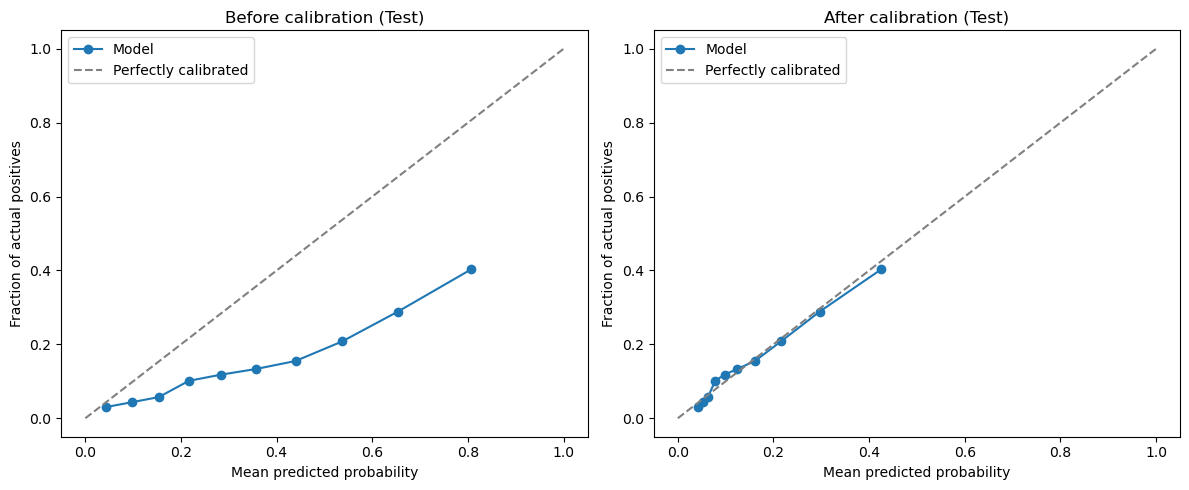

In [91]:
# ------------------------------------------------------------------
# 13. RELIABILITY DIAGRAM — before vs after calibration (test set)
# ------------------------------------------------------------------
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, proba, title in [(axes[0], test_proba, 'Before calibration'),
                          (axes[1], test_proba_cal, 'After calibration')]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label='Model')
    ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfectly calibrated')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of actual positives')
    ax.set_title(f'{title} (Test)')
    ax.legend()

plt.tight_layout()
plt.show()


In [92]:
# ------------------------------------------------------------------
# 14. THRESHOLD SELECTION — maximize F1 on VALIDATION (never on test)
# ------------------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score

prec_v, rec_v, thresh_v = precision_recall_curve(y_valid, valid_proba_cal)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-12)
best_idx = f1_v[:-1].argmax()  # thresh_v is one shorter than prec_v/rec_v
best_threshold = thresh_v[best_idx]

print(f'Best F1-maximizing threshold (from validation): {best_threshold:.4f}')
print(f'At that threshold on validation -> precision: {prec_v[best_idx]:.4f}, '
      f'recall: {rec_v[best_idx]:.4f}, F1: {f1_v[best_idx]:.4f}')

candidate_thresholds = sorted(set([0.1, 0.2, 0.3, round(float(best_threshold), 4), 0.5, 0.7]))
rows = []
for t in candidate_thresholds:
    pred_t = (valid_proba_cal >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_valid, pred_t, zero_division=0),
        'recall': recall_score(y_valid, pred_t, zero_division=0),
        'f1': f1_score(y_valid, pred_t, zero_division=0),
        'predicted_npl_ratio': pred_t.mean(),
    })

display(pd.DataFrame(rows))


Best F1-maximizing threshold (from validation): 0.2191
At that threshold on validation -> precision: 0.3359, recall: 0.5224, F1: 0.4088


,threshold,precision,recall,f1,predicted_npl_ratio
0,0.1000,0.228938,0.786471,0.354642,0.528555
1,0.2000,0.317407,0.558824,0.404858,0.270884
2,0.2191,0.335603,0.521765,0.408473,0.239207
3,0.3000,0.400262,0.358824,0.378412,0.137931
4,0.5000,0.582734,0.047647,0.088091,0.012580
5,0.7000,0.000000,0.000000,0.000000,0.000000


--- Test @ threshold=0.2191 (calibrated) ---
ROC AUC: 0.7338
PR AUC : 0.3379
              precision    recall  f1-score   support

           0     0.9013    0.8063    0.8511     11687
           1     0.3256    0.5144    0.3988      2125

    accuracy                         0.7614     13812
   macro avg     0.6134    0.6603    0.6250     13812
weighted avg     0.8127    0.7614    0.7815     13812



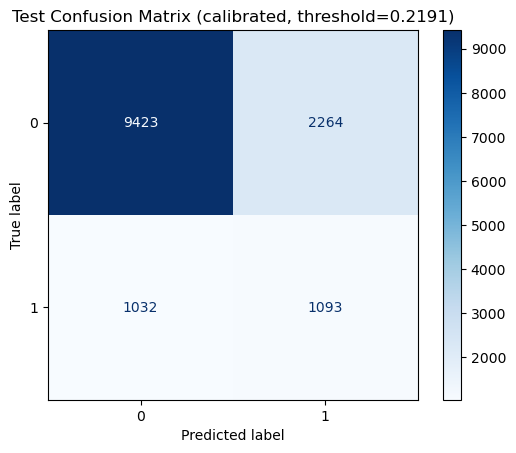

Actual test NPL ratio:            15.3852%
Model-predicted test NPL ratio:    15.5682%  (calibrated mean probability)


In [93]:
# ------------------------------------------------------------------
# 15. FINAL TEST EVALUATION — calibrated probabilities @ chosen threshold
# ------------------------------------------------------------------
test_pred_final = (test_proba_cal >= best_threshold).astype(int)

print(f'--- Test @ threshold={best_threshold:.4f} (calibrated) ---')
print('ROC AUC:', round(roc_auc_score(y_test, test_proba_cal), 4))
print('PR AUC :', round(average_precision_score(y_test, test_proba_cal), 4))
print(classification_report(y_test, test_pred_final, digits=4))

cm = confusion_matrix(y_test, test_pred_final)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title(f'Test Confusion Matrix (calibrated, threshold={best_threshold:.4f})')
plt.show()

print(f'Actual test NPL ratio:            {y_test.mean():.4%}')
print(f'Model-predicted test NPL ratio:    {test_proba_cal.mean():.4%}  (calibrated mean probability)')


In [94]:
# ------------------------------------------------------------------
# 16. SAVE THE TRAINED MODEL (+ calibrator, threshold, and dtype metadata)
# ------------------------------------------------------------------
import joblib

model.save_model(MODEL_OUT_PATH)
print('Base model saved to:', MODEL_OUT_PATH)

# XGBoost's enable_categorical encodes categories by their position in each
# column's CategoricalDtype -- inference must reconstruct the EXACT same
# categories in the EXACT same order, or predictions will be silently wrong
# rather than erroring. Persist them here instead of relying on the trained
# booster alone.
category_maps = {col: X_train[col].cat.categories.tolist() for col in cat_cols}

MODEL_BUNDLE_PATH = MODEL_OUT_PATH.with_name('xgb_npl_model_calibrated.joblib')
joblib.dump(
    {
        'calibrated_model': calibrated_model,
        'threshold': float(best_threshold),
        'feature_cols': feature_cols,
        'bool_cols': bool_cols,
        'cat_cols': cat_cols,
        'category_maps': category_maps,
    },
    MODEL_BUNDLE_PATH,
)
print('Calibrated model + threshold + dtype metadata saved to:', MODEL_BUNDLE_PATH)

# To reload later:
# loaded_model = xgb.XGBClassifier()
# loaded_model.load_model(MODEL_OUT_PATH)
#
# bundle = joblib.load(MODEL_BUNDLE_PATH)
# calibrated_model, threshold, feature_cols = bundle['calibrated_model'], bundle['threshold'], bundle['feature_cols']


Base model saved to: C:\Users\koemhort.leng\Desktop\EWS_NPL_V2\EDA\feature_selection_output\xgb_npl_model.json
Calibrated model + threshold + dtype metadata saved to: C:\Users\koemhort.leng\Desktop\EWS_NPL_V2\EDA\feature_selection_output\xgb_npl_model_calibrated.joblib


## Out-of-Time Validation

The random split above shuffles rows regardless of origination date, so it can't tell you
whether the model generalizes to *future* vintages — the actual deployment scenario. This
section rebuilds train/valid/test as a **chronological** split by `APP_DATE` instead: train on
the oldest ~70% of originations, validate on the next ~20%, test on the newest ~10% (all still
within the mature, non-censored population from the maturity filter).

Source: `ready_for_featrue_selection.csv` (post maturity-filter, pre-feature-selection —
carries `APP_DATE`, which the leak-free feature file does not). Restricted to the same
`feature_cols` used above, with exact-duplicate rows dropped to match the main pipeline's
dedup step. Outlier IQR-capping from `remove_outlier_feature_store.ipynb` is not reapplied
here — a reasonable simplification for a validation check, not the production pipeline.

In [95]:
# ------------------------------------------------------------------
# 17. LOAD + PREP THE OOT SOURCE (carries APP_DATE)
# ------------------------------------------------------------------
READY_PATH = pathlib.Path(r'C:\Users\koemhort.leng\Desktop\EWS_NPL_V2\EDA\ready_for_featrue_selection.csv')

oot_df = pd.read_csv(READY_PATH)
print('Loaded:', READY_PATH, 'shape:', oot_df.shape)

keep_cols = feature_cols + [TARGET_COL, 'APP_DATE']
missing = [c for c in keep_cols if c not in oot_df.columns]
if missing:
    raise ValueError(f'Columns missing from OOT source: {missing}')

oot_df = oot_df[keep_cols].copy()
before = len(oot_df)
oot_df = oot_df.drop_duplicates().reset_index(drop=True)
print(f'Dropped {before - len(oot_df)} exact-duplicate rows (matching main pipeline dedup)')

oot_df['APP_DATE'] = pd.to_datetime(oot_df['APP_DATE'], errors='coerce')
oot_df = oot_df.sort_values('APP_DATE').reset_index(drop=True)
print('Shape after dedup:', oot_df.shape)
print('Date range:', oot_df['APP_DATE'].min(), 'to', oot_df['APP_DATE'].max())


Loaded: C:\Users\koemhort.leng\Desktop\EWS_NPL_V2\EDA\ready_for_featrue_selection.csv shape: (85342, 91)
Dropped 2138 exact-duplicate rows (matching main pipeline dedup)
Shape after dedup: (83204, 16)
Date range: 2018-11-16 00:00:00 to 2024-02-29 00:00:00


In [96]:
# ------------------------------------------------------------------
# 18. CHRONOLOGICAL 70/20/10 SPLIT BY APP_DATE
# ------------------------------------------------------------------
n = len(oot_df)
train_cut = oot_df['APP_DATE'].iloc[int(n * 0.7)]
valid_cut = oot_df['APP_DATE'].iloc[int(n * 0.9)]

oot_train_df = oot_df[oot_df['APP_DATE'] <= train_cut].copy()
oot_valid_df = oot_df[(oot_df['APP_DATE'] > train_cut) & (oot_df['APP_DATE'] <= valid_cut)].copy()
oot_test_df = oot_df[oot_df['APP_DATE'] > valid_cut].copy()

print(f'Train cutoff: <= {train_cut.date()}   Valid cutoff: <= {valid_cut.date()}   Test: after that')
for name, d in [('OOT train', oot_train_df), ('OOT valid', oot_valid_df), ('OOT test', oot_test_df)]:
    print(f'{name}: {d.shape}  NPL ratio: {d[TARGET_COL].mean():.4%}  '
          f'({d["APP_DATE"].min().date()} to {d["APP_DATE"].max().date()})')


Train cutoff: <= 2023-10-26   Valid cutoff: <= 2024-01-19   Test: after that
OOT train: (58412, 16)  NPL ratio: 14.0108%  (2018-11-16 to 2023-10-26)
OOT valid: (16852, 16)  NPL ratio: 20.4545%  (2023-10-27 to 2024-01-19)
OOT test: (7940, 16)  NPL ratio: 22.7834%  (2024-01-20 to 2024-02-29)


In [97]:
# ------------------------------------------------------------------
# 18b. TIME-TREND FEATURE — months since the earliest origination in the OOT set
# ------------------------------------------------------------------
# Lets the model explicitly learn "vintage X had rate Y" instead of that signal
# being absorbed indirectly/noisily through other correlated features.
# Caveat: XGBoost splits on value ranges seen in training and can't extrapolate
# a trend past them -- OOT test dates are strictly newer than anything in OOT
# train, so the model can bucket them as "the newest cohort seen" but can't
# project the trend forward the way a linear model would. Included here as an
# honest test of whether it helps, not a guaranteed fix for the OOT gap.
REF_DATE = oot_df['APP_DATE'].min()

for d in (oot_train_df, oot_valid_df, oot_test_df):
    d['MONTHS_SINCE_START'] = (
        (d['APP_DATE'].dt.year - REF_DATE.year) * 12
        + (d['APP_DATE'].dt.month - REF_DATE.month)
    )

oot_feature_cols = feature_cols + ['MONTHS_SINCE_START']
print('Reference date:', REF_DATE.date())
for name, d in [('OOT train', oot_train_df), ('OOT valid', oot_valid_df), ('OOT test', oot_test_df)]:
    print(f'{name}: MONTHS_SINCE_START range {d["MONTHS_SINCE_START"].min()}-{d["MONTHS_SINCE_START"].max()}')


Reference date: 2018-11-16
OOT train: MONTHS_SINCE_START range 0-59
OOT valid: MONTHS_SINCE_START range 59-62
OOT test: MONTHS_SINCE_START range 62-63


In [98]:
# ------------------------------------------------------------------
# 19. DTYPE ALIGNMENT FOR THE OOT SPLITS (same approach as the main split)
# ------------------------------------------------------------------
oot_bool_cols = oot_train_df[oot_feature_cols].select_dtypes(include='bool').columns.tolist()
oot_cat_cols = oot_train_df[oot_feature_cols].select_dtypes(include='object').columns.tolist()

for d in (oot_train_df, oot_valid_df, oot_test_df):
    for col in oot_bool_cols:
        d[col] = d[col].astype('int8')

for col in oot_cat_cols:
    all_categories = pd.concat(
        [oot_train_df[col], oot_valid_df[col], oot_test_df[col]]
    ).astype(str).unique()
    cat_dtype = pd.CategoricalDtype(categories=sorted(all_categories))
    for d in (oot_train_df, oot_valid_df, oot_test_df):
        d[col] = d[col].astype(str).astype(cat_dtype)

X_oot_train, y_oot_train = oot_train_df[oot_feature_cols], oot_train_df[TARGET_COL]
X_oot_valid, y_oot_valid = oot_valid_df[oot_feature_cols], oot_valid_df[TARGET_COL]
X_oot_test, y_oot_test = oot_test_df[oot_feature_cols], oot_test_df[TARGET_COL]

oot_neg, oot_pos = (y_oot_train == 0).sum(), (y_oot_train == 1).sum()
oot_scale_pos_weight = oot_neg / oot_pos
print(f'OOT train class balance -> neg: {oot_neg}, pos: {oot_pos}, scale_pos_weight: {oot_scale_pos_weight:.3f}')


OOT train class balance -> neg: 50228, pos: 8184, scale_pos_weight: 6.137


In [99]:
# ------------------------------------------------------------------
# 20. TRAIN A FRESH MODEL ON THE OOT SPLIT (same hyperparameters as the main model)
# ------------------------------------------------------------------
oot_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='aucpr',
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=oot_scale_pos_weight,
    random_state=RANDOM_STATE,
    early_stopping_rounds=50,
    n_jobs=-1,
)

oot_model.fit(
    X_oot_train, y_oot_train,
    eval_set=[(X_oot_train, y_oot_train), (X_oot_valid, y_oot_valid)],
    verbose=50,
)

print('OOT best iteration:', oot_model.best_iteration)


[0]	validation_0-aucpr:0.38119	validation_1-aucpr:0.31893
[50]	validation_0-aucpr:0.53138	validation_1-aucpr:0.36542
[100]	validation_0-aucpr:0.57388	validation_1-aucpr:0.37353
[150]	validation_0-aucpr:0.60449	validation_1-aucpr:0.37829
[200]	validation_0-aucpr:0.62958	validation_1-aucpr:0.38166
[250]	validation_0-aucpr:0.65094	validation_1-aucpr:0.38526
[300]	validation_0-aucpr:0.67178	validation_1-aucpr:0.38900
[350]	validation_0-aucpr:0.69250	validation_1-aucpr:0.39161
[400]	validation_0-aucpr:0.71180	validation_1-aucpr:0.39516
[450]	validation_0-aucpr:0.72840	validation_1-aucpr:0.39656
[500]	validation_0-aucpr:0.74458	validation_1-aucpr:0.39735
[550]	validation_0-aucpr:0.75872	validation_1-aucpr:0.39740
[558]	validation_0-aucpr:0.76141	validation_1-aucpr:0.39705
OOT best iteration: 508


--- OOT Validation ---
ROC AUC: 0.7034
PR AUC : 0.3967
              precision    recall  f1-score   support

           0     0.8770    0.6364    0.7376     13405
           1     0.3158    0.6527    0.4257      3447

    accuracy                         0.6397     16852
   macro avg     0.5964    0.6446    0.5816     16852
weighted avg     0.7622    0.6397    0.6738     16852



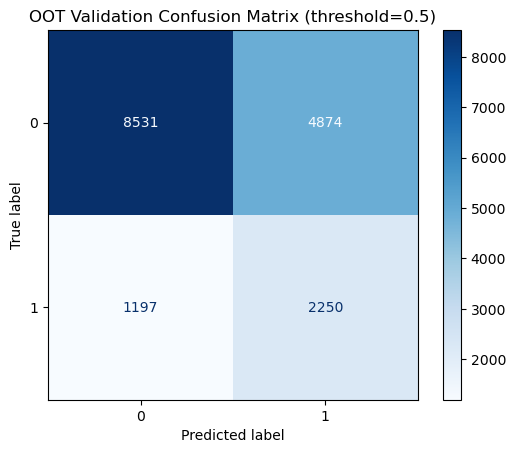

--- OOT Test ---
ROC AUC: 0.7024
PR AUC : 0.4107
              precision    recall  f1-score   support

           0     0.8621    0.6426    0.7364      6131
           1     0.3499    0.6517    0.4553      1809

    accuracy                         0.6447      7940
   macro avg     0.6060    0.6472    0.5958      7940
weighted avg     0.7454    0.6447    0.6723      7940



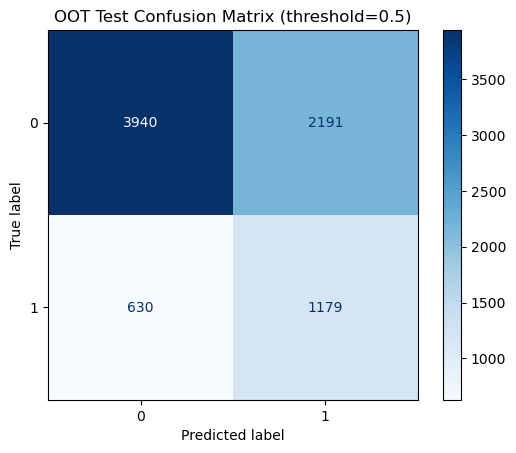

In [100]:
# ------------------------------------------------------------------
# 21. EVALUATE THE OOT MODEL ON OOT VALID & OOT TEST
# ------------------------------------------------------------------
oot_valid_proba, oot_valid_pred = evaluate('OOT Validation', X_oot_valid, y_oot_valid, oot_model)
oot_test_proba, oot_test_pred = evaluate('OOT Test', X_oot_test, y_oot_test, oot_model)


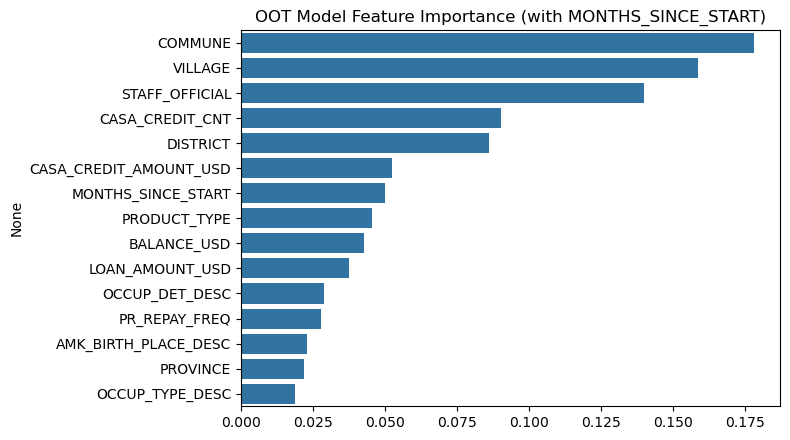

COMMUNE                   0.178083
VILLAGE                   0.158373
STAFF_OFFICIAL            0.139893
CASA_CREDIT_CNT           0.090041
DISTRICT                  0.086104
CASA_CREDIT_AMOUNT_USD    0.052412
MONTHS_SINCE_START        0.049889
PRODUCT_TYPE              0.045514
BALANCE_USD               0.042561
LOAN_AMOUNT_USD           0.037493
OCCUP_DET_DESC            0.028661
PR_REPAY_FREQ             0.027702
AMK_BIRTH_PLACE_DESC      0.022860
PROVINCE                  0.021833
OCCUP_TYPE_DESC           0.018580
dtype: float32

MONTHS_SINCE_START rank: 7 of 15


In [101]:
# ------------------------------------------------------------------
# 21b. OOT FEATURE IMPORTANCE — did MONTHS_SINCE_START actually help?
# ------------------------------------------------------------------
oot_importance = pd.Series(
    oot_model.feature_importances_, index=oot_feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(8, max(4, len(oot_importance) * 0.3)))
sns.barplot(x=oot_importance.values, y=oot_importance.index, orient='h')
plt.title('OOT Model Feature Importance (with MONTHS_SINCE_START)')
plt.tight_layout()
plt.show()

display(oot_importance)
print(f"MONTHS_SINCE_START rank: {list(oot_importance.index).index('MONTHS_SINCE_START') + 1} of {len(oot_importance)}")


In [ ]:
# ------------------------------------------------------------------
# 22. RANDOM-SPLIT vs OUT-OF-TIME COMPARISON (test sets)
# ------------------------------------------------------------------
comparison = pd.DataFrame([
    {
        'split': 'Random (test)',
        'roc_auc': roc_auc_score(y_test, test_proba),
        'pr_auc': average_precision_score(y_test, test_proba),
        'actual_npl_ratio': y_test.mean(),
        'predicted_npl_ratio': test_proba.mean(),
    },
    {
        'split': 'Out-of-time (test)',
        'roc_auc': roc_auc_score(y_oot_test, oot_test_proba),
        'pr_auc': average_precision_score(y_oot_test, oot_test_proba),
        'actual_npl_ratio': y_oot_test.mean(),
        'predicted_npl_ratio': oot_test_proba.mean(),
    },
])
display(comparison)

gap = comparison.iloc[0]['pr_auc'] - comparison.iloc[1]['pr_auc']
print(f'PR AUC gap (random - OOT): {gap:.4f}')
print('A small gap means the model generalizes to future vintages about as well as it does to')
print('random held-out rows -- a good sign for production. A large gap (OOT much worse) means')
print('the random split was overstating real-world performance, and this OOT number is the')
print('more honest expectation for deployment.')


,split,roc_auc,pr_auc,actual_npl_ratio,predicted_npl_ratio
0,Random (test),0.733764,0.337898,0.153852,0.358869
1,Out-of-time (test),0.702416,0.410709,0.227834,0.448193


PR AUC gap (random - OOT): -0.0728
A small gap means the model generalizes to future vintages about as well as it does to
random held-out rows -- a good sign for production. A large gap (OOT much worse) means
the random split was overstating real-world performance, and this OOT number is the
more honest expectation for deployment.


: 